In [1]:
import requests
import pandas as pd
import plotly.express as px

In [2]:
# IMF  = Interplanetary Magnetic Field

# Measured in Bx, By, Bz..

# Bx = sun to earth direction
# By = Sideways Magnetic Field
# Bz > 0 Earth Resists Interaction
# Bz < 0 Earth Connects more easily

In [3]:
url  = "https://services.swpc.noaa.gov/products/solar-wind/mag-7-day.json"

response  = requests.get(url)

print(response.status_code)

200


In [4]:
data = response.json()

print(type(data))
print(len(data))

<class 'list'>
9622


In [5]:
print(data[0])

['time_tag', 'bx_gsm', 'by_gsm', 'bz_gsm', 'lon_gsm', 'lat_gsm', 'bt']


In [6]:
print(data[1])

['2026-06-14 07:10:00.000', '3.52', '-4.52', '0.96', '307.95', '9.53', '5.81']


In [7]:
df = pd.DataFrame(data[1:], columns =data[0])
df.head()

,time_tag,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt
0,2026-06-14 07:10:00.000,3.52,-4.52,0.96,307.95,9.53,5.81
1,2026-06-14 07:11:00.000,3.33,-4.47,1.26,306.69,12.73,5.76
2,2026-06-14 07:12:00.000,3.25,-4.59,1.42,305.29,14.20,5.82
3,2026-06-14 07:13:00.000,4.27,-3.87,-0.03,317.86,-0.28,5.79
4,2026-06-14 07:14:00.000,4.21,-4.04,-0.15,316.15,-1.44,5.84


In [8]:
print(type(data))

<class 'list'>


In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9621 entries, 0 to 9620
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   time_tag  9621 non-null   str  
 1   bx_gsm    9621 non-null   str  
 2   by_gsm    9621 non-null   str  
 3   bz_gsm    9621 non-null   str  
 4   lon_gsm   9621 non-null   str  
 5   lat_gsm   9621 non-null   str  
 6   bt        9621 non-null   str  
dtypes: str(7)
memory usage: 526.3 KB
None


In [12]:
df["time_tag"] = pd.to_datetime(df["time_tag"])

numeric_cols = ["bx_gsm","by_gsm","bz_gsm","lon_gsm","lat_gsm","bt"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors = "coerce")

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9621 entries, 0 to 9620
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   time_tag  9621 non-null   datetime64[us]
 1   bx_gsm    9621 non-null   float64       
 2   by_gsm    9621 non-null   float64       
 3   bz_gsm    9621 non-null   float64       
 4   lon_gsm   9621 non-null   float64       
 5   lat_gsm   9621 non-null   float64       
 6   bt        9621 non-null   float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 526.3 KB


In [14]:
df.describe()

,time_tag,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt
count,9621,9621.000000,9621.000000,9621.000000,9621.000000,9621.000000,9621.000000
mean,2026-06-17 20:21:17.517929,-0.268463,0.749452,0.560177,169.194995,4.625826,5.998755
min,2026-06-14 07:10:00,-9.650000,-8.290000,-7.510000,0.030000,-87.120000,0.620000
25%,2026-06-16 04:05:00,-2.980000,-2.840000,-1.540000,83.500000,-16.370000,4.690000
50%,2026-06-17 20:38:00,0.280000,1.120000,0.350000,142.300000,3.980000,5.960000
75%,2026-06-19 13:17:00,2.770000,3.980000,2.230000,271.490000,24.380000,7.110000
max,2026-06-21 05:39:00,6.280000,9.930000,11.400000,359.970000,87.170000,12.000000
std,NaN,3.570646,3.983898,3.098889,105.794662,32.198783,1.892050


In [15]:
df.loc[df["bz_gsm"].idxmin()]

time_tag    2026-06-16 13:47:00
bx_gsm                     1.73
by_gsm                     -0.6
bz_gsm                    -7.51
lon_gsm                   340.9
lat_gsm                  -76.26
bt                         7.75
Name: 2974, dtype: object

In [16]:
# usally at daytime earths magnetic field generally points northward
# therefore negative IMF Bz means southward 
# Opposite magnetic fields meeting leads to magnetic reconnection which make energy transfer easy into the earth

In [17]:
(df["bz_gsm"]<0).sum()

np.int64(4194)

In [18]:
(df["bz_gsm"]>0).sum()

np.int64(5408)

In [19]:
(df["bz_gsm"]==0).sum()

np.int64(19)

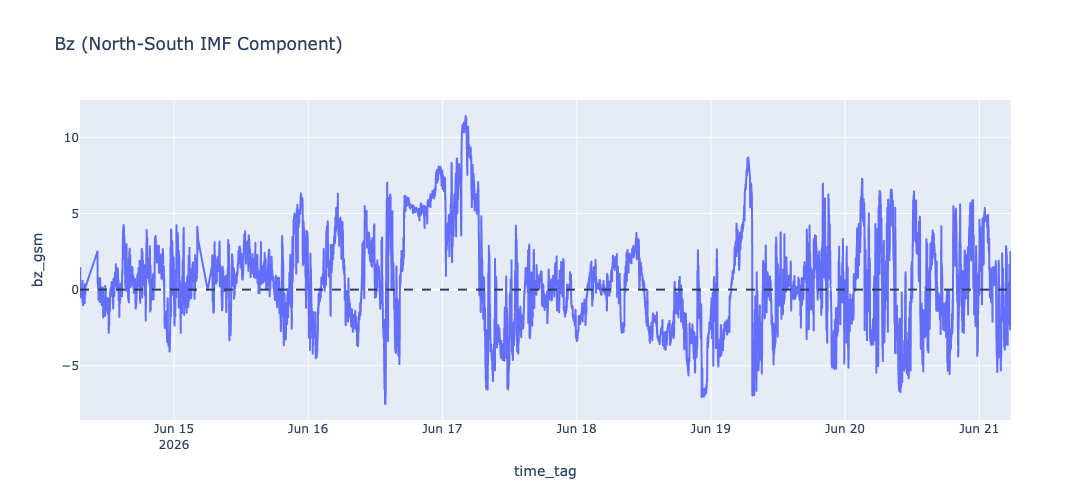

In [23]:


fig = px.line(
    df,
    x="time_tag",
    y="bz_gsm",
    title="Bz (North-South IMF Component)"
)

fig.update_layout(
    width=1200,
    height=500
)
fig.add_hline(
    y=0,
    line_dash="dash"
)

fig

In [24]:
df["bt"].describe()

count    9621.000000
mean        5.998755
std         1.892050
min         0.620000
25%         4.690000
50%         5.960000
75%         7.110000
max        12.000000
Name: bt, dtype: float64

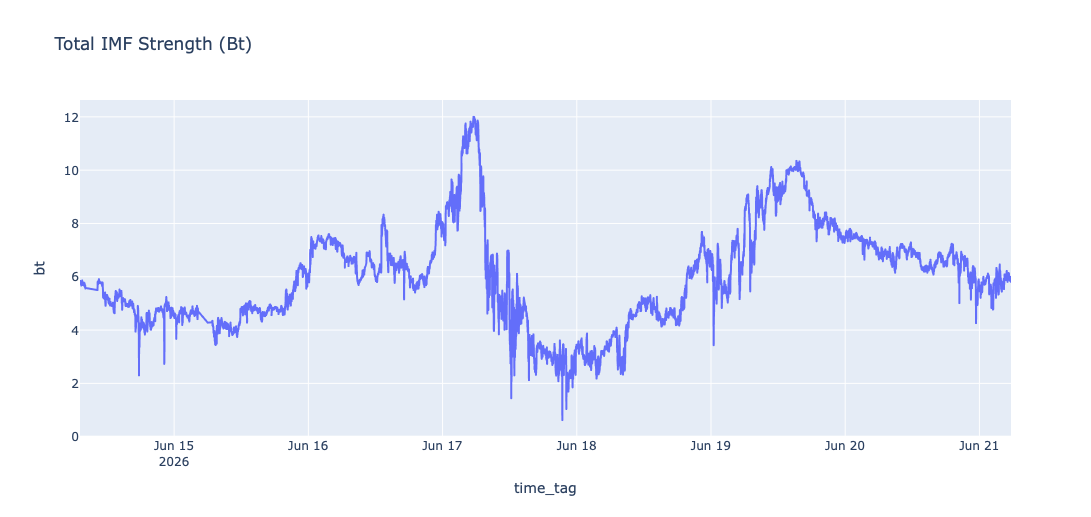

In [25]:
fig = px.line(
    df,
    x="time_tag",
    y="bt",
    title="Total IMF Strength (Bt)"
)

fig.update_layout(
    width=1200,
    height=500
)

fig

In [26]:
# Direction Matters Bz
# Strength Matters Bt

In [27]:
df.loc[df["bt"].idxmax()]

time_tag    2026-06-17 05:32:00
bx_gsm                      3.1
by_gsm                     8.77
bz_gsm                     7.58
lon_gsm                   70.55
lat_gsm                    39.2
bt                         12.0
Name: 3918, dtype: object

In [28]:
#Strong field alone does not imply
# geomagnetic storm potential.

# Bz direction remains critical


In [29]:
df[["bx_gsm","by_gsm","bz_gsm","bt"]].corr()

,bx_gsm,by_gsm,bz_gsm,bt
bx_gsm,1.000000,-0.279328,-0.036278,-0.511995
by_gsm,-0.279328,1.000000,-0.032568,0.321211
bz_gsm,-0.036278,-0.032568,1.000000,0.246508
bt,-0.511995,0.321211,0.246508,1.000000


In [30]:
# Bz behaves largely Independent (Bx & By)

# Day 4 Bonus Analysis

In [31]:
solar_url = "https://services.swpc.noaa.gov/products/solar-wind/plasma-7-day.json"

solar_response = requests.get(solar_url)

solar_data = solar_response.json()

In [32]:
solar_df = pd.DataFrame(
    solar_data[1:],
    columns=solar_data[0]
)

In [33]:
solar_df.head()

,time_tag,density,speed,temperature
0,2026-06-14 07:10:00.000,11.42,540.2,446560
1,2026-06-14 07:11:00.000,11.72,539.5,446916
2,2026-06-14 07:12:00.000,11.64,539.5,444788
3,2026-06-14 07:13:00.000,3.54,528.8,66615
4,2026-06-14 07:14:00.000,3.31,531.0,107487


In [34]:
solar_df["time_tag"] = pd.to_datetime(solar_df["time_tag"])

for col in ["density", "speed", "temperature"]:
    solar_df[col] = pd.to_numeric(
        solar_df[col],
        errors="coerce"
    )

In [35]:
solar_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9463 entries, 0 to 9462
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time_tag     9463 non-null   datetime64[us]
 1   density      9463 non-null   float64       
 2   speed        9463 non-null   float64       
 3   temperature  9463 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(1)
memory usage: 295.8 KB


In [36]:
merged_df = pd.merge(
    solar_df,
    df,
    on="time_tag",
    how="inner"
)

In [37]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9426 entries, 0 to 9425
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time_tag     9426 non-null   datetime64[us]
 1   density      9426 non-null   float64       
 2   speed        9426 non-null   float64       
 3   temperature  9426 non-null   int64         
 4   bx_gsm       9426 non-null   float64       
 5   by_gsm       9426 non-null   float64       
 6   bz_gsm       9426 non-null   float64       
 7   lon_gsm      9426 non-null   float64       
 8   lat_gsm      9426 non-null   float64       
 9   bt           9426 non-null   float64       
dtypes: datetime64[us](1), float64(8), int64(1)
memory usage: 736.5 KB


In [38]:
merged_df[
    [
        "density",
        "speed",
        "temperature",
        "bx_gsm",
        "by_gsm",
        "bz_gsm",
        "bt"
    ]
].corr()

,density,speed,temperature,bx_gsm,by_gsm,bz_gsm,bt
density,1.000000,0.057381,0.062869,0.189098,-0.002947,0.250883,0.124385
speed,0.057381,1.000000,0.807622,0.353933,-0.502534,0.046041,-0.324676
temperature,0.062869,0.807622,1.000000,0.209947,-0.402480,-0.181068,-0.285467
bx_gsm,0.189098,0.353933,0.209947,1.000000,-0.273305,-0.038632,-0.525211
by_gsm,-0.002947,-0.502534,-0.402480,-0.273305,1.000000,-0.039448,0.327246
bz_gsm,0.250883,0.046041,-0.181068,-0.038632,-0.039448,1.000000,0.246388
bt,0.124385,-0.324676,-0.285467,-0.525211,0.327246,0.246388,1.000000


Merged Solar Wind and IMF analysis showed that
solar wind speed, density, and temperature have
little relationship with Bz orientation.

The strongest relationship observed was between
speed and temperature (0.81).

This suggests that plasma properties and magnetic
field orientation should be analyzed separately
when assessing space weather conditions.

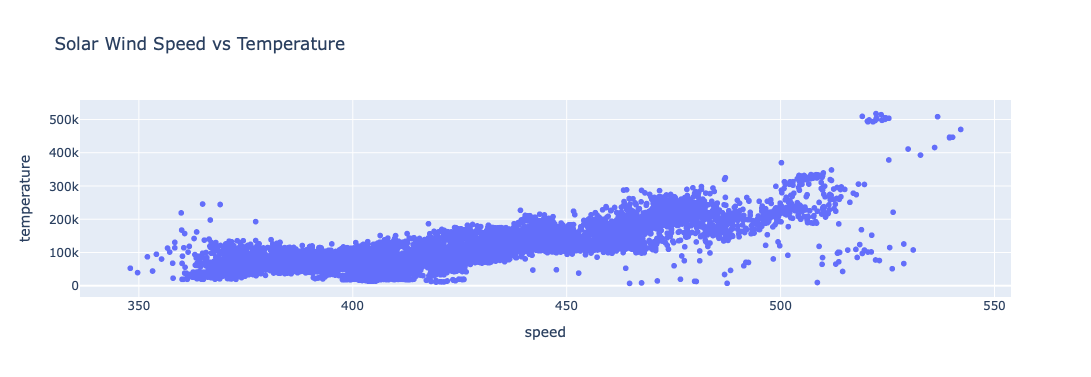

In [39]:
import plotly.express as px

fig = px.scatter(
    merged_df,
    x="speed",
    y="temperature",
    title="Solar Wind Speed vs Temperature"
)

fig

# Bz Persistance


In [40]:
df["negative_bz"] = df["bz_gsm"] < 0

In [41]:
groups = (df["negative_bz"] != df["negative_bz"].shift()).cumsum()

In [42]:
df["group"] = groups

In [43]:
negative_intervals = (
    df[df["negative_bz"]]
    .groupby("group")
    .size()
)

In [44]:
negative_intervals.max()

np.int64(318)

In [45]:
longest_group = negative_intervals.idxmax()

longest_group

np.int64(382)

In [46]:
longest_event = df[df["group"] == longest_group]

longest_event.head()

,time_tag,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt,negative_bz,group
5723,2026-06-18 12:06:00,5.06,0.01,-0.27,0.09,-3.02,5.07,True,382
5724,2026-06-18 12:07:00,5.04,-0.24,-0.54,357.27,-6.10,5.07,True,382
5725,2026-06-18 12:08:00,4.99,-0.40,-0.57,355.44,-6.45,5.04,True,382
5726,2026-06-18 12:09:00,4.96,-0.67,-0.55,352.35,-6.30,5.03,True,382
5727,2026-06-18 12:10:00,4.94,-0.99,-0.49,348.71,-5.58,5.06,True,382


In [47]:
longest_event.tail()

,time_tag,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt,negative_bz,group
6036,2026-06-18 17:22:00,1.98,3.02,-2.99,56.69,-39.65,4.72,True,382
6037,2026-06-18 17:23:00,2.03,3.01,-3.02,56.05,-39.74,4.73,True,382
6038,2026-06-18 17:24:00,1.89,3.22,-2.81,59.62,-36.94,4.67,True,382
6039,2026-06-18 17:25:00,2.10,3.13,-2.74,56.10,-36.04,4.67,True,382
6040,2026-06-18 17:26:00,3.37,3.33,-0.58,44.65,-6.95,4.82,True,382


In [48]:
start_time = longest_event["time_tag"].min()
end_time = longest_event["time_tag"].max()

print(start_time)
print(end_time)

2026-06-18 12:06:00
2026-06-18 17:26:00


In [49]:
duration = end_time - start_time

print(duration)

0 days 05:20:00
